<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/13_lesson_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notekis (masalan, exponential yoki uniform) taqsimotdan 10,000 ta populyatsiya elementi generatsiya qiling (np.random.exponential).



In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
population = np.random.exponential(scale=2, size=10000)

Shu populyatsiyadan n=5, n=30, n=100 hajmdagi 1000 tadan random sample oling (np.random.choice, replace=False yoki with replacement — talabaga izohlab bering).


In [2]:
sample_sizes = [5, 30, 100]
results = {}

Har bir sample uchun sample mean hisoblang, natijalarni ro'yxatga yig'ing.


In [3]:
for n in sample_sizes:
    means = []
    for _ in range(1000):
        sample = np.random.choice(population, size=n, replace=True)
        means.append(sample.mean())
    results[n] = np.array(means)

Har bir n uchun sample means histogram qiling (3 ta subplot — n=5, 30, 100 yonma-yon) va CLT ta'sirini vizual ko'rsating (n oshgani sari normal shaklga yaqinlashishini).


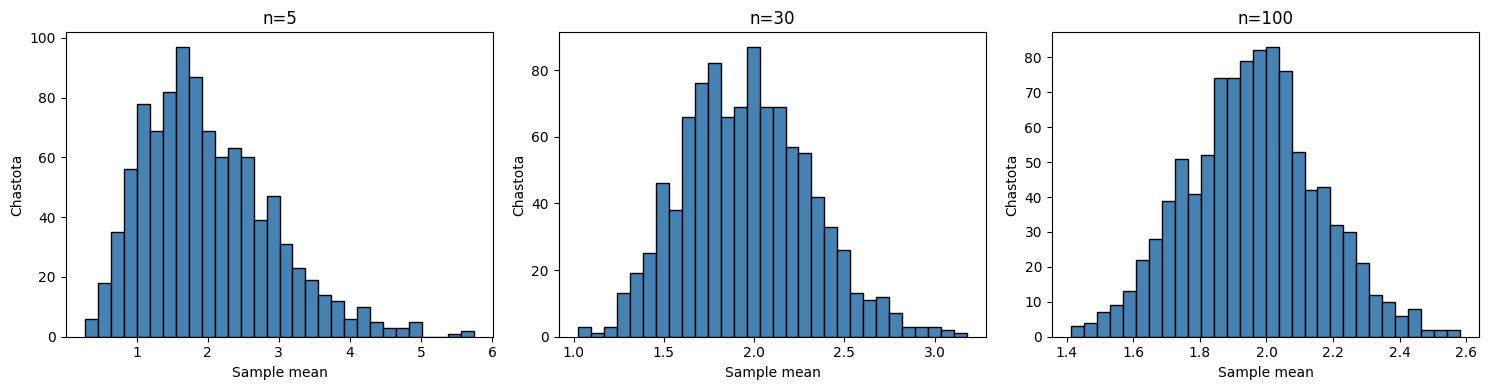

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, sample_sizes):
    ax.hist(results[n], bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'n={n}')
    ax.set_xlabel('Sample mean')
    ax.set_ylabel('Chastota')

plt.tight_layout()
plt.show()

Har bir n uchun sample means'ning standart og'ishini hisoblang va uni nazariy standard error (σ/√n) bilan solishtiring.


In [6]:
print(f"{'n':<6}{'Amaliy std':<15}{'Nazariy SE':<15}")
for n in sample_sizes:
    empirical_std = results[n].std()
    theoretical_se = population.std() / np.sqrt(n)
    print(f"{n:<6}{empirical_std:<15.4f}{theoretical_se:<15.4f}")

n     Amaliy std     Nazariy SE     
5     0.9070         0.8715         
30    0.3521         0.3558         
100   0.1991         0.1949         


Xulosa yozdiring: nega n katta bo'lganda sampling distribution normal bo'lib qoladi, garchi original populyatsiya normal bo'lmasa ham.


In [ ]:
# Populyatsiya exponensial bo'lsa ham, sample hajmi n katta bo'lgani sari sample means'larning taqsimoti normal shaklga yaqinlashadi
# va tarqoqligi 1/sqrt(n) qonuni bilan kamayadi. Bu Markaziy Limit Teoremasi tufayli sodir bo'ladi